In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '9_datasets.xlsx'
dfs = pd.read_excel(file_path, sheet_name=None)

for sheet_name, df in dfs.items():
    print(f"Sheet name: {sheet_name}")
    print(df) 

Sheet name: Bette Rae
     Overall Site ID Gender        Date of Birth Race Date of Round  Visit ID  \
0             1001.0      F  1946-03-17 00:00:00   AA    2016-10-04     931.0   
1                NaN    NaN                  NaN  NaN    2017-05-22    1014.0   
2                NaN    NaN                  NaN  NaN    2017-08-08    1048.0   
3                NaN    NaN                  NaN  NaN    2017-10-31    1067.0   
4                NaN    NaN                  NaN  NaN    2018-02-06    1086.0   
..               ...    ...                  ...  ...           ...       ...   
533           1239.0      F  1953-09-11 00:00:00   AA    2023-04-19    1562.0   
534              NaN    NaN                  NaN  NaN    2024-01-17    1613.0   
535              NaN    NaN                  NaN  NaN           NaT       NaN   
536           1251.0      F  1949-11-07 00:00:00   AA    2023-04-19    1564.0   
537              NaN    NaN                  NaN  NaN    2023-08-09    1600.0   

     

In [2]:
participant_counts = {}

for sheet in dfs:
    df = pd.read_excel(file_path, sheet_name=sheet)
    participant_counts[sheet] = df['Overall Site ID'].nunique()

for sheet, count in participant_counts.items():
    print(f"Number of unique participants in '{sheet}': {count}")

Number of unique participants in 'Bette Rae': 97
Number of unique participants in 'David B.Waymer': 76
Number of unique participants in 'Eastway': 90
Number of unique participants in 'Mallard Creek': 75
Number of unique participants in 'Northern': 20
Number of unique participants in 'Southview': 81
Number of unique participants in 'Tyvola': 129
Number of unique participants in 'West Charlotte': 72


In [3]:
age_counts = {}

for sheet in dfs:
    df = pd.read_excel(file_path, sheet_name=sheet)
    age_counts[sheet] = df['Age (yrs)'].notnull().sum()  

for sheet, count in age_counts.items():
    print(f"Number of non-null entries in 'Age' column for '{sheet}': {count}")

Number of non-null entries in 'Age' column for 'Bette Rae': 442
Number of non-null entries in 'Age' column for 'David B.Waymer': 267
Number of non-null entries in 'Age' column for 'Eastway': 352
Number of non-null entries in 'Age' column for 'Mallard Creek': 236
Number of non-null entries in 'Age' column for 'Northern': 45
Number of non-null entries in 'Age' column for 'Southview': 331
Number of non-null entries in 'Age' column for 'Tyvola': 480
Number of non-null entries in 'Age' column for 'West Charlotte': 389


C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\558788106.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = combined_df.groupby('Age Group')[columns_to_plot].mean()


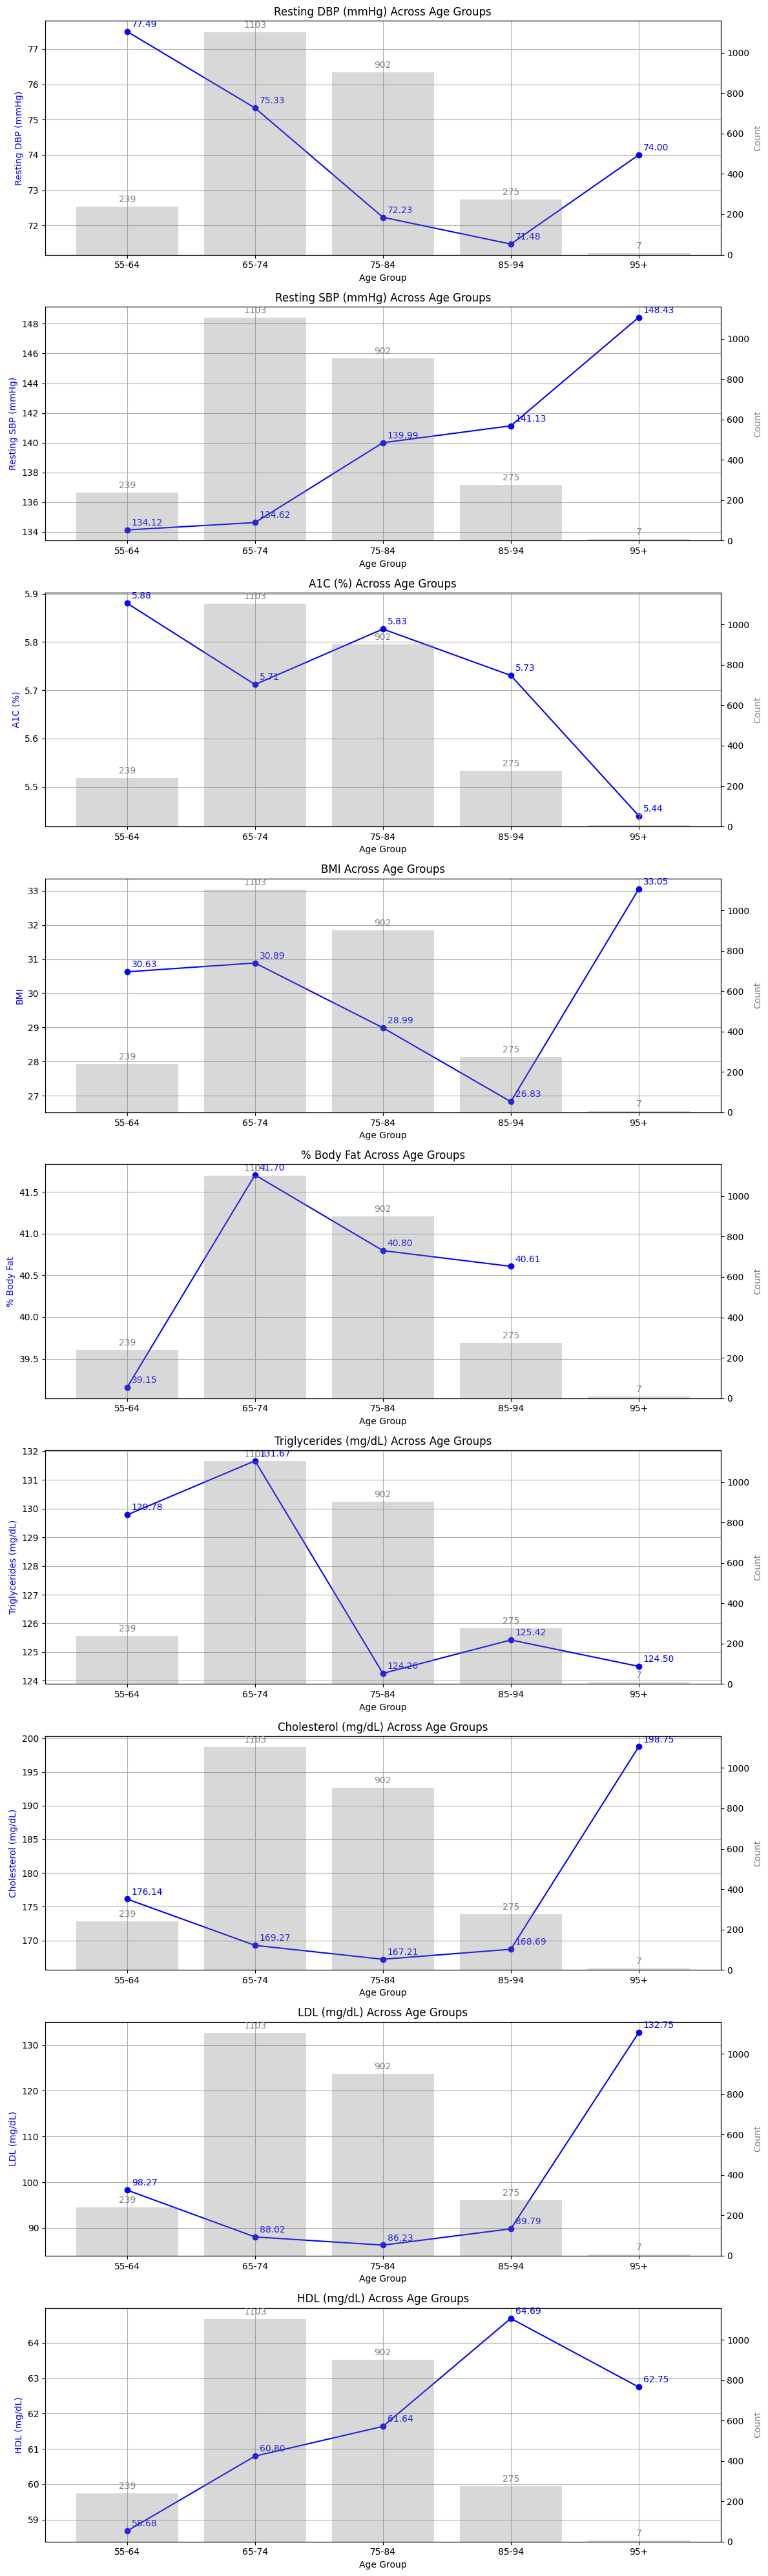

In [4]:
age_bins = [55, 65, 75, 85, 95, float('inf')]  # Age cutoffs
age_labels = ['55-64', '65-74', '75-84', '85-94', '95+']
combined_df = pd.concat(dfs.values(), ignore_index=True)

combined_df['Age Group'] = pd.cut(combined_df['Age (yrs)'], bins=age_bins, labels=age_labels, right=False)

columns_to_plot = ['Resting DBP (mmHg)', 'Resting SBP (mmHg)', 'A1C (%)', 'BMI', '% Body Fat', 'Triglycerides (mg/dL)', 'Cholesterol (mg/dL)', 'LDL (mg/dL)',  'HDL (mg/dL)' ]
grouped_df = combined_df.groupby('Age Group')[columns_to_plot].mean()
counts = combined_df['Age Group'].value_counts().reindex(age_labels)

fig, axes = plt.subplots(nrows=len(columns_to_plot), ncols=1, figsize=(12, 40))

for i, column in enumerate(columns_to_plot):
    ax1 = axes[i] 
    ax2 = ax1.twinx()  
    ax1.plot(grouped_df.index, grouped_df[column], marker='o', color='b', label=column)
    ax1.set_title(f'{column} Across Age Groups')
    ax1.set_xlabel('Age Group')
    ax1.set_ylabel(column, color='b')
    ax1.grid(True)
    ax2.bar(grouped_df.index, counts, alpha=0.3, color='gray', label='Count')
    ax2.set_ylabel('Count', color='gray')

    for j, val in enumerate(grouped_df[column]):
        ax1.annotate(f'{val:.2f}', xy=(j, val), xytext=(5, 5), textcoords='offset points', color='b', fontsize=10)

    for j, val in enumerate(counts):
        ax2.annotate(f'{val}', xy=(j, val), xytext=(0, 5), textcoords='offset points', ha='center', color='gray', fontsize=10)

plt.tight_layout()
plt.show()


Highest quarter for Resting DBP (mmHg):
      Year  Quarter  avg_metric  num_people
0   2016.0        3   73.578947          19
5   2017.0        4   74.830357         112
7   2018.0        2   74.795455         132
10  2019.0        1   74.072289         166
15  2020.0        2   74.520000          25
16  2021.0        4   77.750000          32
17  2022.0        1   77.850000         120
22  2023.0        2   77.984848          66
27  2024.0        3   77.538462          26


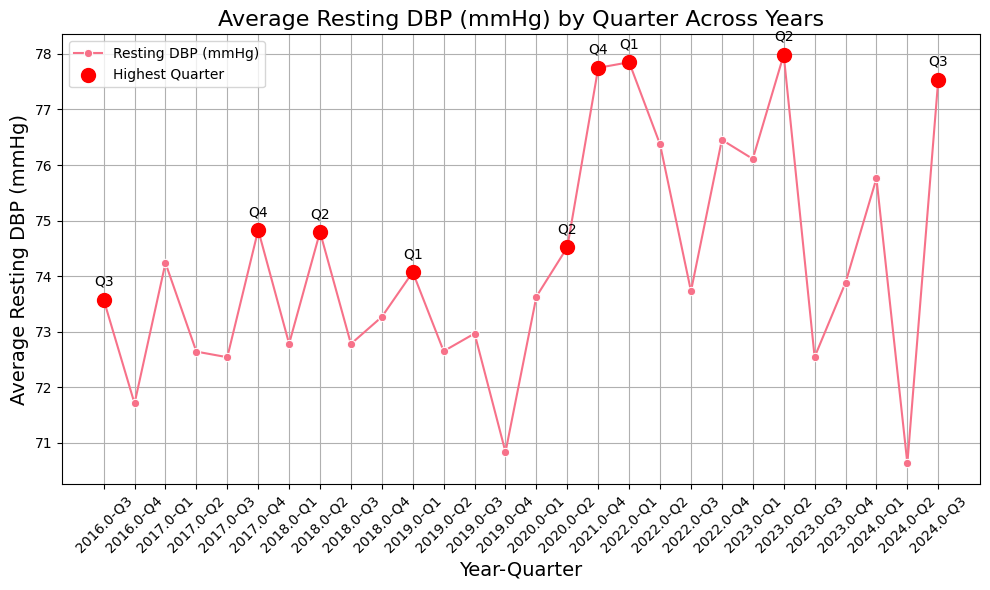


Highest quarter for Resting SBP (mmHg):
      Year  Quarter  avg_metric  num_people
0   2016.0        3  136.800000           5
2   2017.0        1  141.176471          51
7   2018.0        2  138.235294         119
13  2019.0        4  138.052632         114
15  2020.0        2  140.600000          25
16  2021.0        4  142.625000          32
17  2022.0        1  142.466667         105
22  2023.0        2  142.954545          66
27  2024.0        3  144.000000           6


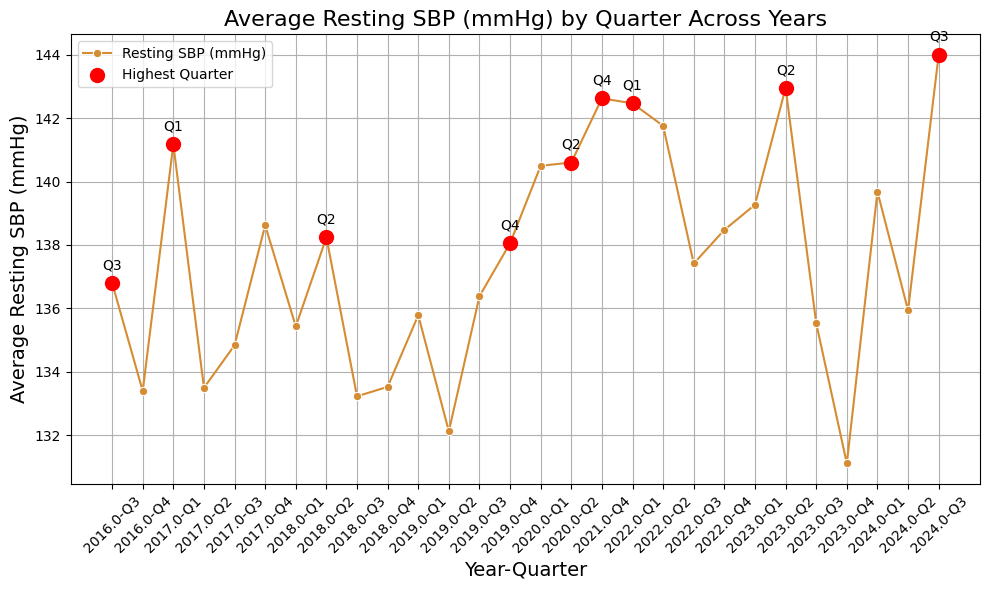


Highest quarter for A1C (%):
      Year  Quarter  avg_metric  num_people
1   2016.0        4    6.101887          53
2   2017.0        1    6.033333          51
6   2018.0        1    5.808871         124
12  2019.0        3    5.855172          87
15  2020.0        2    6.068182          22
16  2021.0        4    5.613333          30
18  2022.0        2    5.759420          69
22  2023.0        2    5.808065          62
25  2024.0        1    5.817500          80


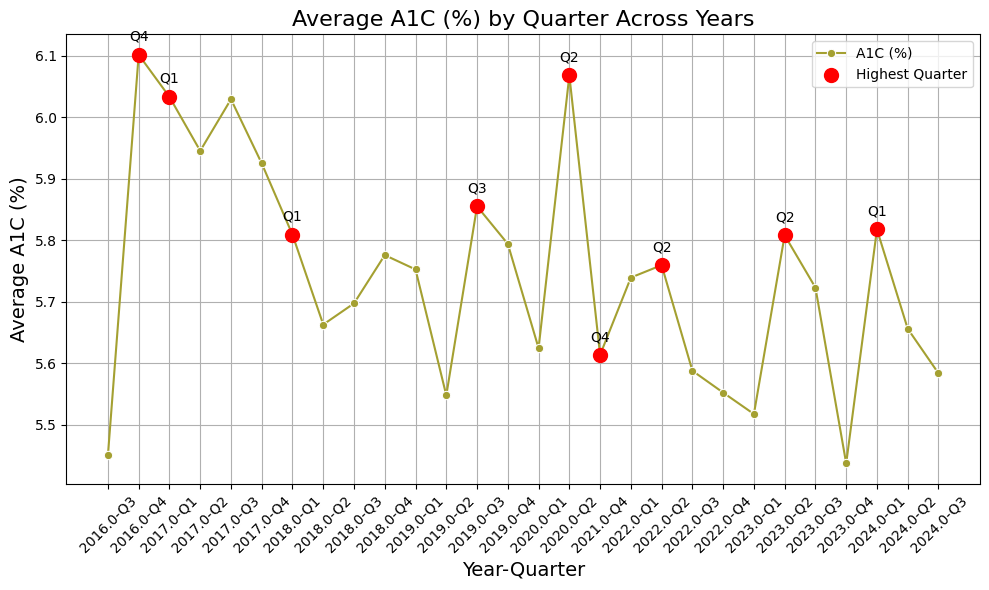


Highest quarter for BMI:
      Year  Quarter  avg_metric  num_people
0   2016.0        3   29.864706          17
3   2017.0        2   30.618992         119
9   2018.0        4   30.501099          91
10  2019.0        1   29.564662         133
14  2020.0        1   29.633333         120
16  2021.0        4   30.036842          19
17  2022.0        1   30.947222         108
22  2023.0        2   30.562295          61
26  2024.0        2   31.547917          48


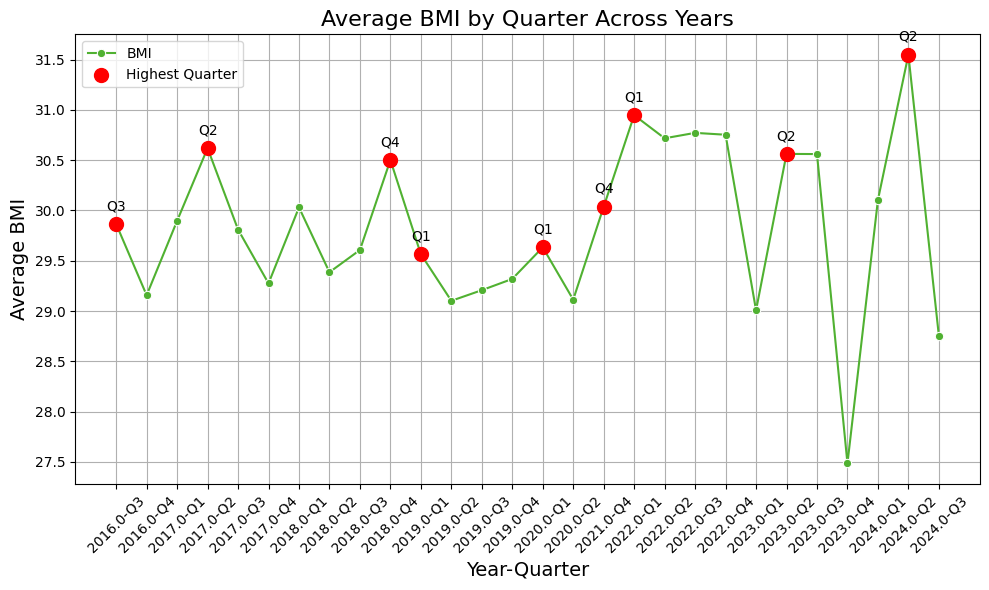


Highest quarter for % Body Fat:
      Year  Quarter  avg_metric  num_people
1   2016.0        4   41.157143          56
2   2017.0        1   41.602222          45
8   2018.0        3   42.151282          39
12  2019.0        3   41.863636          66
15  2020.0        2   41.372222          18
16  2021.0        4   43.660000          10
20  2022.0        4   43.175610          41
21  2023.0        1   41.157377          61
26  2024.0        2   42.815556          45


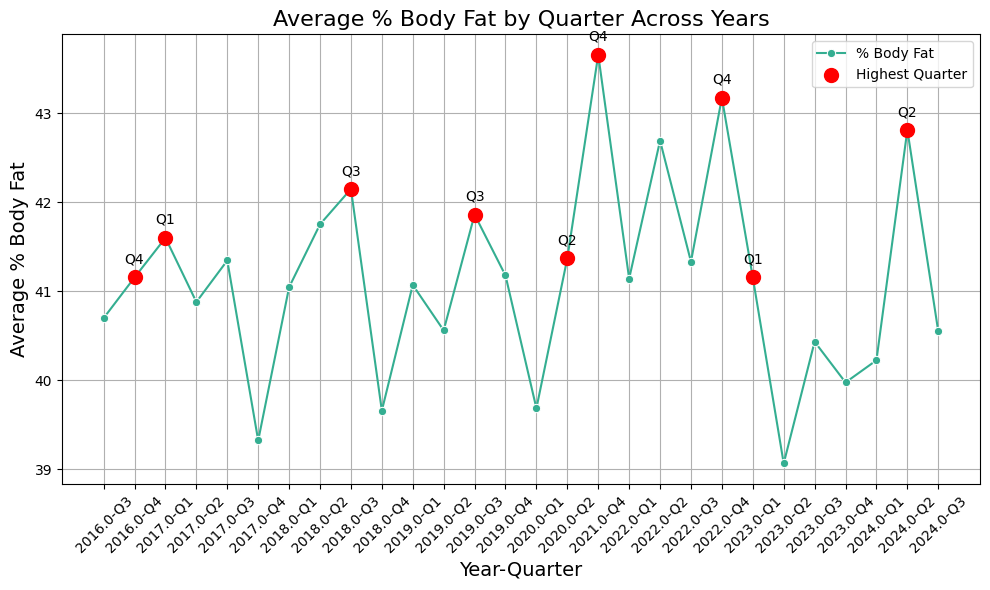


Highest quarter for Triglycerides (mg/dL):
      Year  Quarter  avg_metric  num_people
1   2016.0        4  151.436364          55
2   2017.0        1  146.538462          39
7   2018.0        2  152.663717         113
12  2019.0        3  123.872549         102
14  2020.0        1  119.725490         102
16  2021.0        4  126.571429          21
17  2022.0        1  140.134831          89
21  2023.0        1  122.936709          79
27  2024.0        3  136.000000           6


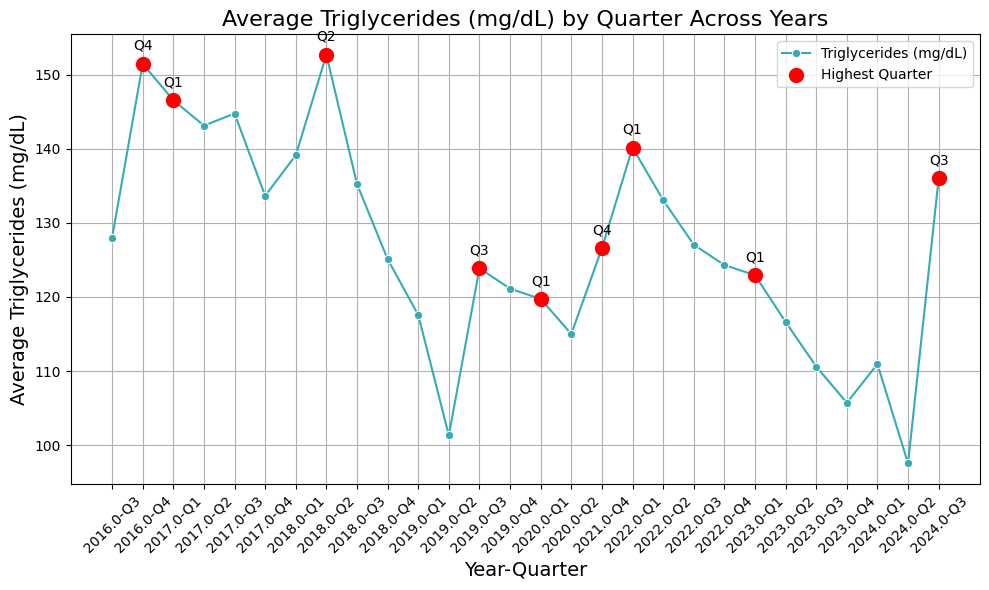


Highest quarter for Cholesterol (mg/dL):
      Year  Quarter  avg_metric  num_people
0   2016.0        3  183.800000           5
2   2017.0        1  174.431373          51
7   2018.0        2  180.559322         118
10  2019.0        1  174.680328         122
14  2020.0        1  177.390000         100
16  2021.0        4  171.000000          21
17  2022.0        1  177.417582          91
21  2023.0        1  175.886076          79
25  2024.0        1  164.666667          78


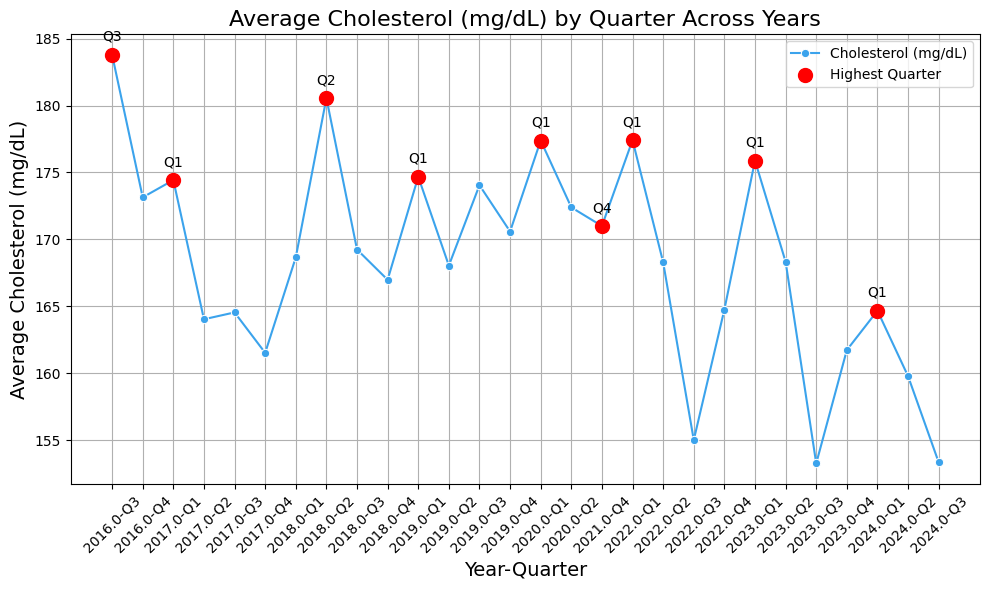


Highest quarter for LDL (mg/dL):
      Year  Quarter  avg_metric  num_people
0   2016.0        3  110.400000           5
2   2017.0        1   95.413043          46
8   2018.0        3   86.046875          64
12  2019.0        3   96.400000          85
14  2020.0        1   92.611111          90
16  2021.0        4   96.214286          14
17  2022.0        1  105.310127          79
21  2023.0        1   96.912281          57
25  2024.0        1   73.428571          56


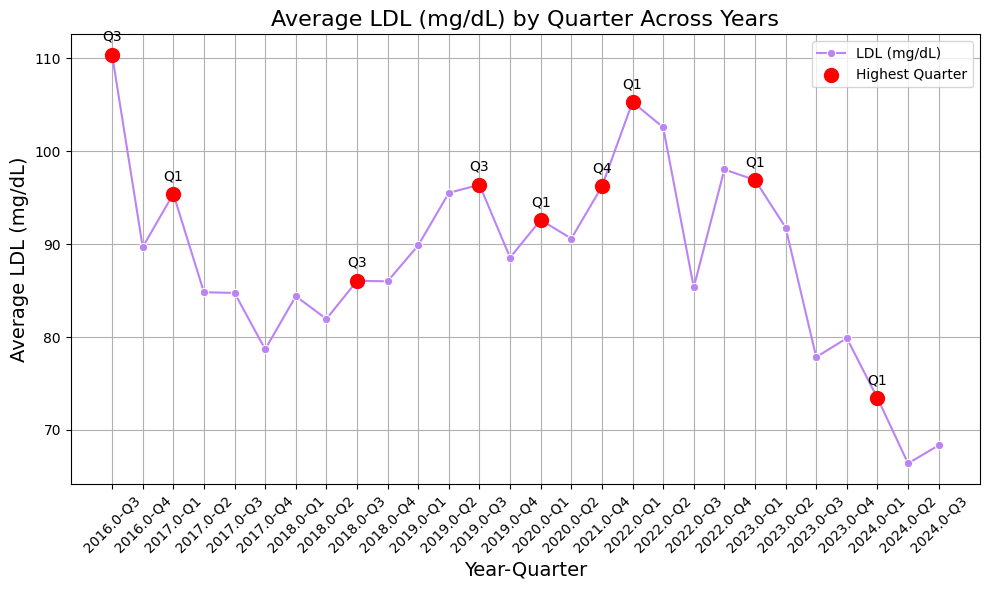


Highest quarter for HDL (mg/dL):
      Year  Quarter  avg_metric  num_people
0   2016.0        3   61.105263          19
5   2017.0        4   60.423077         104
7   2018.0        2   64.439394         132
10  2019.0        1   65.493151         146
14  2020.0        1   61.517544         114
16  2021.0        4   64.047619          21
19  2022.0        3   60.400000          50
22  2023.0        2   64.786885          61
26  2024.0        2   72.433962          53


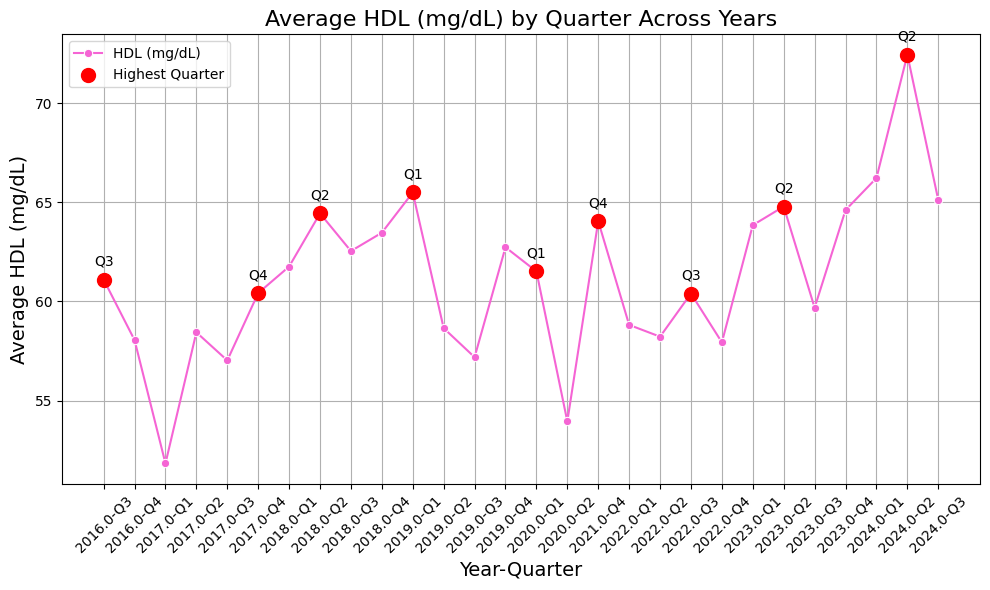


Most frequent highest quarter for each metric:
Resting DBP (mmHg): Q2
Resting SBP (mmHg): Q2
A1C (%): Q1
BMI: Q1
% Body Fat: Q4
Triglycerides (mg/dL): Q1
Cholesterol (mg/dL): Q1
LDL (mg/dL): Q1
HDL (mg/dL): Q2


In [5]:
combined_df['Date of Round'] = pd.to_datetime(combined_df['Date of Round'], errors='coerce')

def assign_quarter(month):
    if month in [1, 2, 3]:
        return 1 
    elif month in [4, 5, 6]:
        return 2 
    elif month in [7, 8, 9]:
        return 3 
    else:
        return 4 

combined_df['Quarter'] = combined_df['Date of Round'].dt.month.apply(assign_quarter)
combined_df['Year'] = combined_df['Date of Round'].dt.year
combined_df['Year_Quarter'] = combined_df['Year'].astype(str) + '-Q' + combined_df['Quarter'].astype(str)

metrics = ['Resting DBP (mmHg)', 'Resting SBP (mmHg)', 'A1C (%)', 'BMI', '% Body Fat', 'Triglycerides (mg/dL)', 'Cholesterol (mg/dL)', 'LDL (mg/dL)',  'HDL (mg/dL)']

palette = sns.color_palette("husl", len(metrics))

most_frequent_quarters = {}

for metric in metrics:
    df_metric = combined_df[['Year_Quarter', 'Year', 'Quarter', metric]].dropna()
    df_avg_metric = df_metric.groupby(['Year_Quarter', 'Year', 'Quarter']).agg(
        avg_metric=(metric, 'mean'), num_people=(metric, 'count')
    ).reset_index()
    max_per_year = df_avg_metric.loc[df_avg_metric.groupby('Year')['avg_metric'].idxmax()]

    print(f"\nHighest quarter for {metric}:")
    print(max_per_year[['Year', 'Quarter', 'avg_metric', 'num_people']])
    
    most_frequent_quarter = max_per_year['Quarter'].mode()[0]  # Find the most frequent quarter
    most_frequent_quarters[metric] = most_frequent_quarter

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_avg_metric, x='Year_Quarter', y='avg_metric', 
                 label=metric, color=palette[metrics.index(metric)], marker='o')
    plt.scatter(max_per_year['Year_Quarter'], max_per_year['avg_metric'], color='red', s=100, label='Highest Quarter', zorder=5)
    for idx, row in max_per_year.iterrows():
        plt.annotate(f"Q{row['Quarter']}", (row['Year_Quarter'], row['avg_metric']),
                     textcoords="offset points", xytext=(0,10), ha='center') 

    plt.title(f'Average {metric} by Quarter Across Years', fontsize=16)
    plt.xlabel('Year-Quarter', fontsize=14)
    plt.ylabel(f'Average {metric}', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\nMost frequent highest quarter for each metric:")
for metric, quarter in most_frequent_quarters.items():
    print(f"{metric}: Q{quarter}")

In [6]:
for metric in metrics:
    df_metric = combined_df[['Year_Quarter', 'Year', 'Quarter', metric]].dropna()
    df_avg_metric = df_metric.groupby(['Year_Quarter', 'Year', 'Quarter']).agg(
        avg_metric=(metric, 'mean'), num_people=(metric, 'count')
    ).reset_index()

    min_per_year = df_avg_metric.loc[df_avg_metric.groupby('Year')['avg_metric'].idxmin()]

    print(f"\nSmallest quarter for {metric}:")
    print(min_per_year[['Year', 'Quarter', 'avg_metric', 'num_people']])


Smallest quarter for Resting DBP (mmHg):
      Year  Quarter  avg_metric  num_people
1   2016.0        4   71.708333          72
4   2017.0        3   72.540541         111
8   2018.0        3   72.780220          91
13  2019.0        4   70.833333         114
14  2020.0        1   73.632353         136
16  2021.0        4   77.750000          32
19  2022.0        3   73.730159          63
23  2023.0        3   72.543860          57
26  2024.0        2   70.629032          62

Smallest quarter for Resting SBP (mmHg):
      Year  Quarter  avg_metric  num_people
1   2016.0        4  133.388889          72
3   2017.0        2  133.490909         110
8   2018.0        3  133.220779          77
11  2019.0        2  132.117647          85
14  2020.0        1  140.495935         123
16  2021.0        4  142.625000          32
19  2022.0        3  137.412698          63
24  2023.0        4  131.103448          29
26  2024.0        2  135.935484          62

Smallest quarter for A1C (%):
     


Health Metric: Resting DBP (mmHg)
       Race  avg_metric  count
0        AA   75.342105    418
1     Asian   73.333333      6
2         C   72.940476    168
3  Hispanic   72.950000     20
4    Indian   84.500000      2
5   Italian   85.000000      1
6         O   73.333333      3
7        PI   93.000000      1
8   Spanish   84.000000      1


C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3352983578.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Race'], rotation=45)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


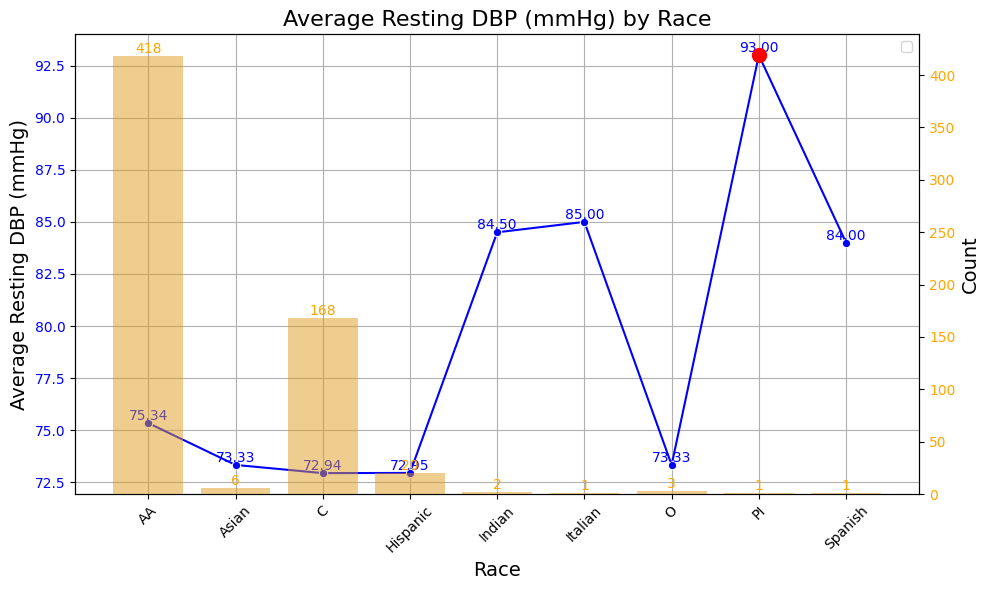


Health Metric: Resting SBP (mmHg)
       Race  avg_metric  count
0        AA  138.584856    383
1     Asian  127.500000      4
2         C  133.853659    123
3  Hispanic  131.615385     13
4    Indian  153.000000      2
5   Italian         NaN      0
6         O  125.666667      3
7        PI         NaN      0
8   Spanish         NaN      0


C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3352983578.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Race'], rotation=45)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


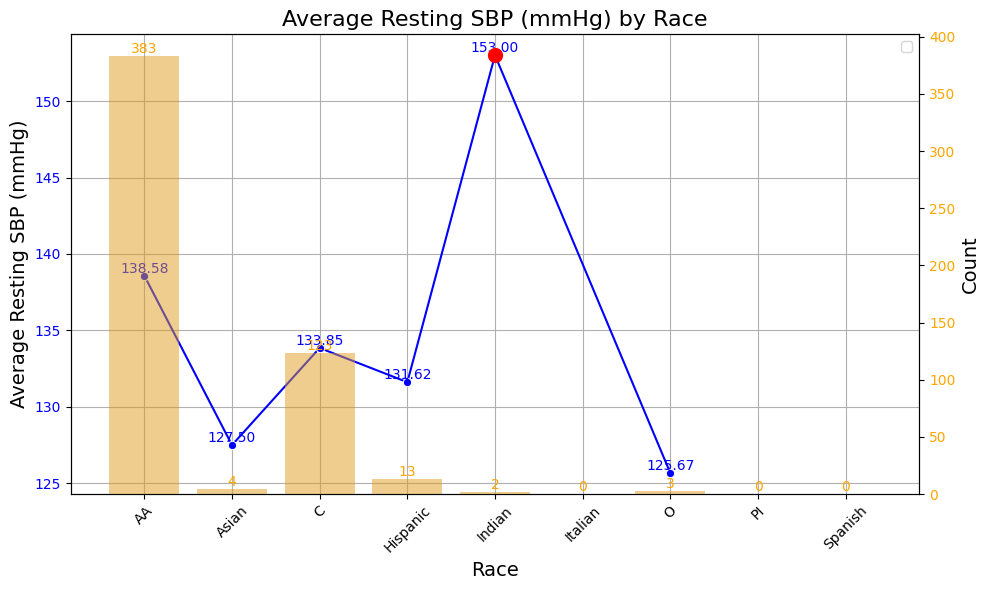


Health Metric: A1C (%)
       Race  avg_metric  count
0        AA    5.963610    349
1     Asian    5.200000      2
2         C    5.587826    115
3  Hispanic    5.584615     13
4    Indian    5.450000      2
5   Italian         NaN      0
6         O    5.833333      3
7        PI         NaN      0
8   Spanish         NaN      0


C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3352983578.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Race'], rotation=45)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


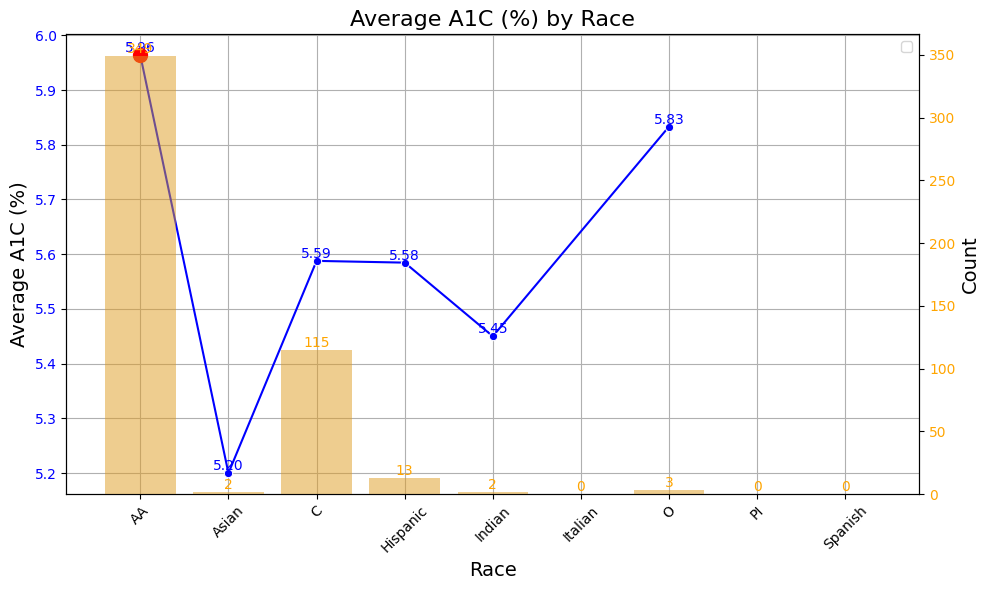


Health Metric: BMI
       Race  avg_metric  count
0        AA   31.346497    354
1     Asian   26.000000      4
2         C   27.240645    155
3  Hispanic   29.800000     19
4    Indian   25.800000      2
5   Italian   25.800000      1
6         O   22.900000      3
7        PI   23.400000      1
8   Spanish   39.000000      1


C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3352983578.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Race'], rotation=45)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


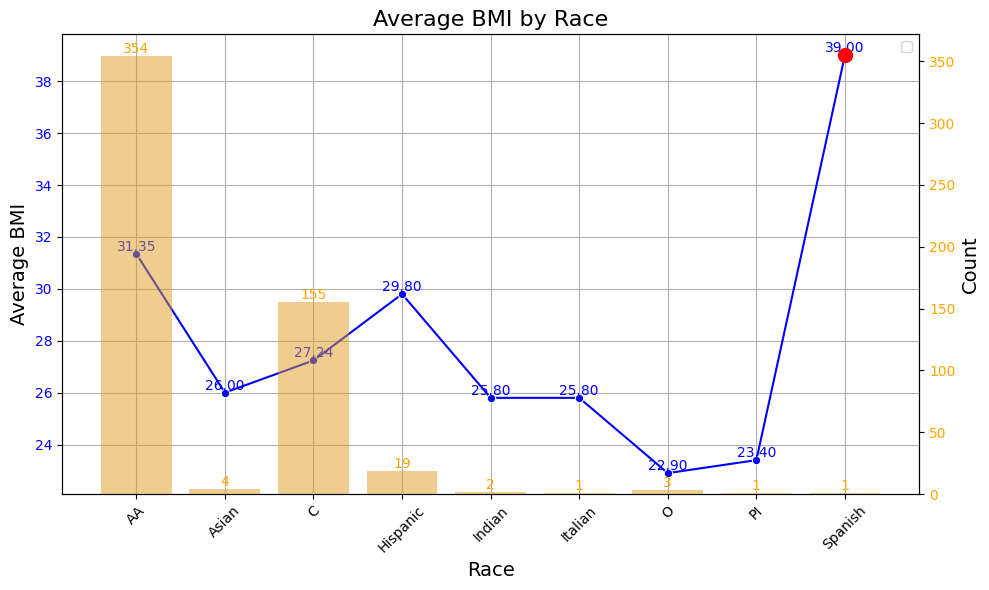


Health Metric: % Body Fat
       Race  avg_metric  count
0        AA   41.101409    232
1     Asian   34.000000      1
2         C   39.615888    107
3  Hispanic   38.875000     12
4    Indian   40.100000      2
5   Italian         NaN      0
6         O   40.833333      3
7        PI         NaN      0
8   Spanish         NaN      0


C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3352983578.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Race'], rotation=45)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


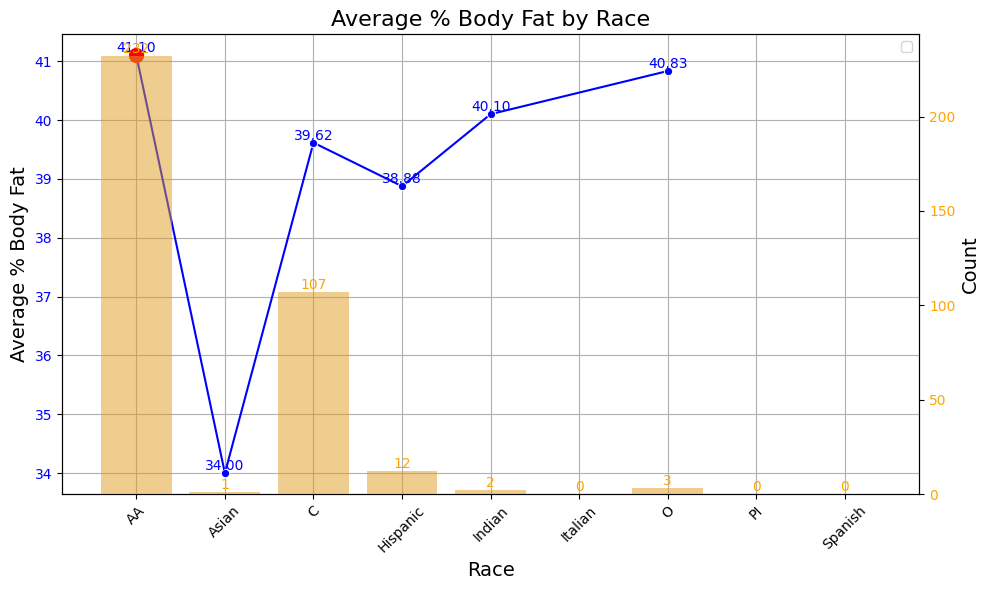


Health Metric: Triglycerides (mg/dL)
       Race  avg_metric  count
0        AA  128.802120    283
1     Asian  264.666667      3
2         C  143.298246    114
3  Hispanic  159.833333     12
4    Indian  105.500000      2
5   Italian         NaN      0
6         O  169.333333      3
7        PI         NaN      0
8   Spanish         NaN      0


C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3352983578.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Race'], rotation=45)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


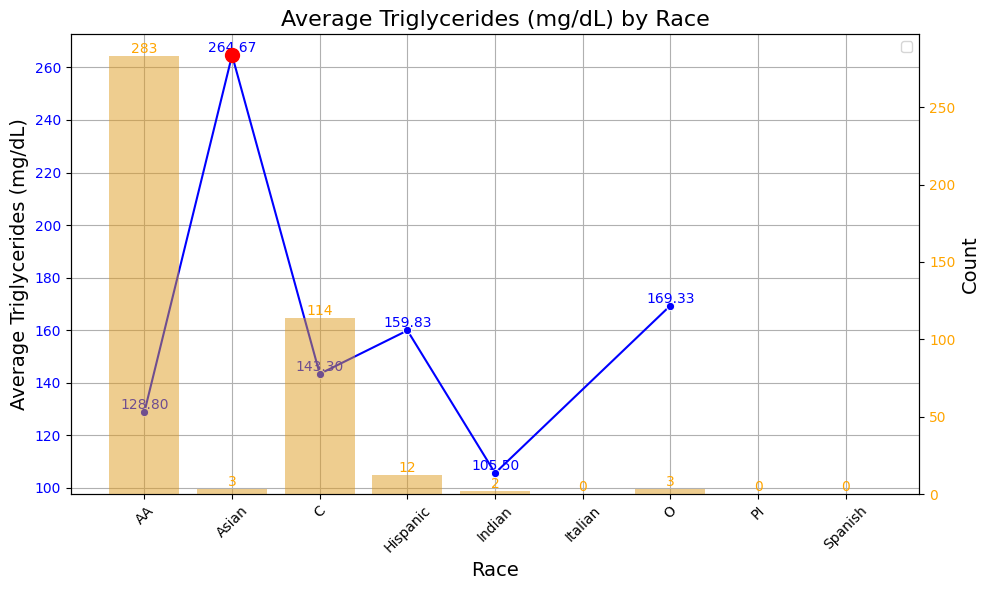


Health Metric: Cholesterol (mg/dL)
       Race  avg_metric  count
0        AA  168.797101    345
1     Asian  176.666667      3
2         C  172.411765    119
3  Hispanic  178.153846     13
4    Indian  144.000000      2
5   Italian         NaN      0
6         O  204.333333      3
7        PI         NaN      0
8   Spanish         NaN      0


C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3352983578.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Race'], rotation=45)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


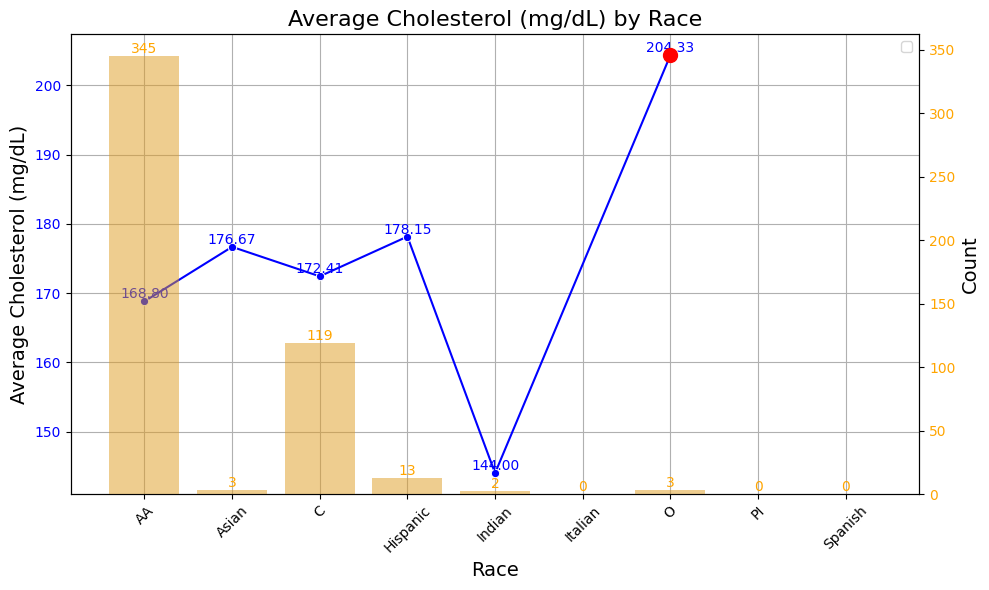


Health Metric: LDL (mg/dL)
       Race  avg_metric  count
0        AA   90.050542    277
1     Asian  118.500000      2
2         C   91.732673    101
3  Hispanic   99.250000     12
4    Indian   92.000000      1
5   Italian         NaN      0
6         O   95.000000      3
7        PI         NaN      0
8   Spanish         NaN      0


C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3352983578.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Race'], rotation=45)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


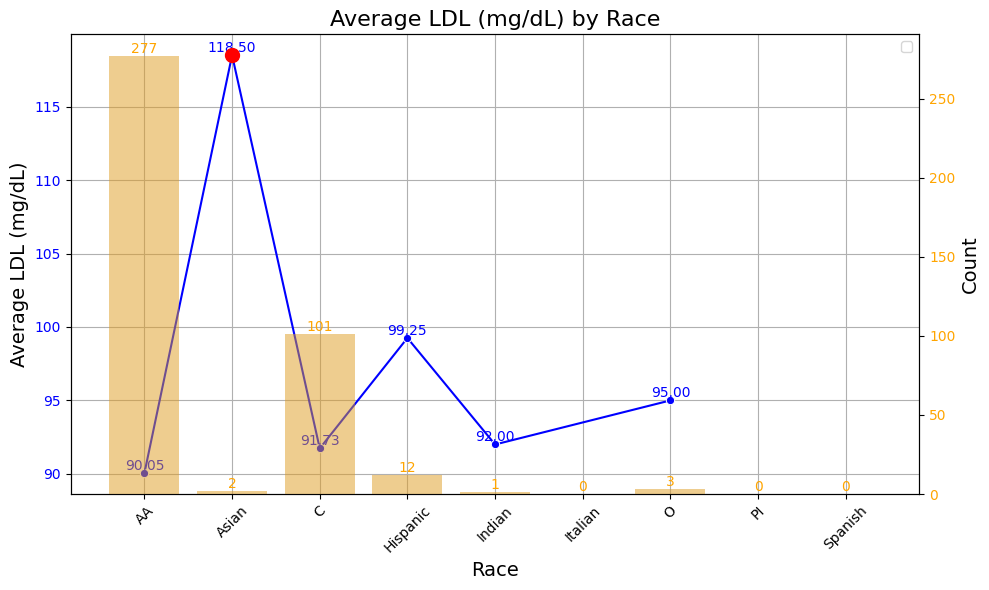

C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3352983578.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Race'], rotation=45)



Health Metric: HDL (mg/dL)
       Race  avg_metric  count
0        AA   61.168865    379
1     Asian   44.750000      4
2         C   59.763975    161
3  Hispanic   58.200000     20
4    Indian   47.000000      2
5   Italian   84.000000      1
6         O   75.000000      3
7        PI  116.000000      1
8   Spanish   33.000000      1


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


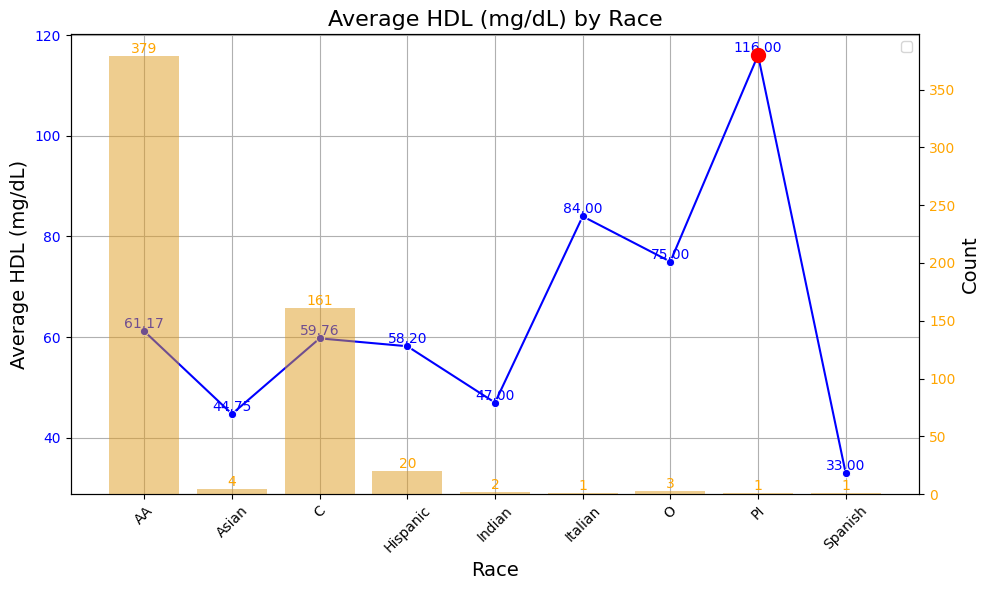

In [27]:
combined_df['Race'] = combined_df['Race'].replace({'H': 'Hispanic'})

metrics = ['Resting DBP (mmHg)', 'Resting SBP (mmHg)', 'A1C (%)', 'BMI', '% Body Fat', 'Triglycerides (mg/dL)', 'Cholesterol (mg/dL)', 'LDL (mg/dL)',  'HDL (mg/dL)']

for metric in metrics:
    df_metric = combined_df.groupby('Race')[metric].agg(
        avg_metric='mean', 
        count='count'
    ).reset_index()

    print(f"\nHealth Metric: {metric}")
    print(df_metric)

    max_value = df_metric['avg_metric'].max()
    max_row = df_metric[df_metric['avg_metric'] == max_value]
    max_race = max_row['Race'].values[0]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    sns.lineplot(data=df_metric, x='Race', y='avg_metric', marker='o', ax=ax1, color='b')
    ax1.set_title(f'Average {metric} by Race', fontsize=16)
    ax1.set_xlabel('Race', fontsize=14)
    ax1.set_ylabel(f'Average {metric}', fontsize=14)
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_xticklabels(df_metric['Race'], rotation=45)
    ax2 = ax1.twinx()
    sns.barplot(data=df_metric, x='Race', y='count', ax=ax2, color='orange', alpha=0.5)
    ax2.set_ylabel('Count', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='orange')

    for i in range(len(df_metric)):
        ax1.text(i, df_metric['avg_metric'].iloc[i], f'{df_metric["avg_metric"].iloc[i]:.2f}', 
                 color='b', ha='center', va='bottom', fontsize=10)
        ax2.text(i, df_metric['count'].iloc[i], f'{df_metric["count"].iloc[i]}', 
                 color='orange', ha='center', va='bottom', fontsize=10)

    ax1.plot(df_metric[df_metric['Race'] == max_race].index, 
             df_metric[df_metric['Race'] == max_race]['avg_metric'], 
             marker='o', markersize=10, color='red', label='Highest Metric', zorder=5)

    ax1.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()

C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3362319180.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aa_df['Age Group'] = pd.cut(aa_df['Age (yrs)'], bins=age_bins, labels=age_labels, right=False)
C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3362319180.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_metric = aa_df.groupby('Age Group')[metric].agg(
C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3362319180.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLo


Health Metric: A1C (%)
  Age Group  avg_metric  count
0     55-64    5.900000     50
1     65-74    5.986538    156
2     75-84    5.971818    110
3     85-94    5.996429     28
4       95+    5.500000      1


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


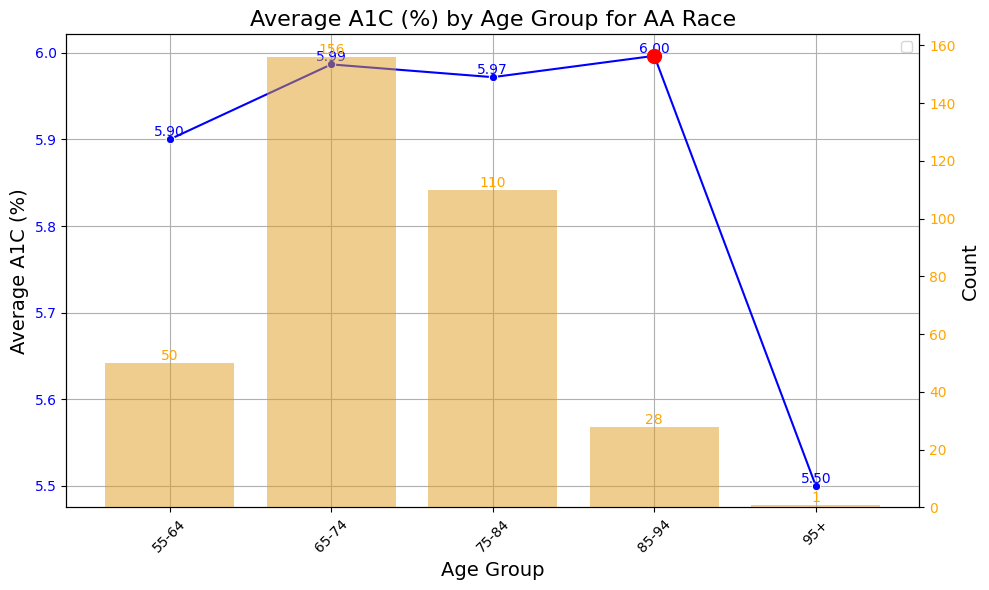

C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3362319180.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_metric = aa_df.groupby('Age Group')[metric].agg(
C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3362319180.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_metric['Age Group'], rotation=45)



Health Metric: BMI
  Age Group  avg_metric  count
0     55-64   31.917544     57
1     65-74   32.411273    165
2     75-84   30.281132    106
3     85-94   26.389474     19
4       95+   33.500000      1


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


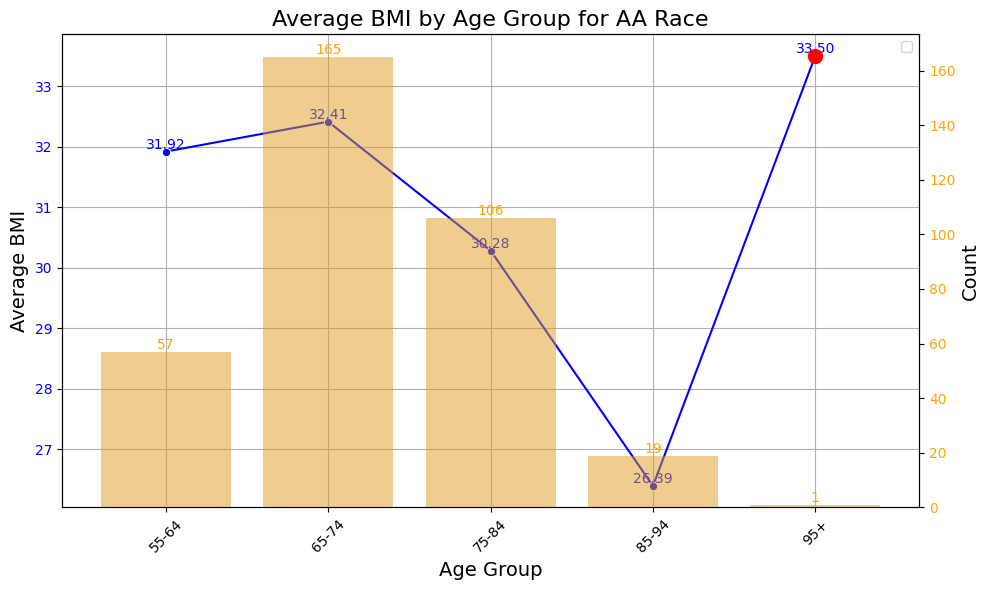

In [28]:
# Replace 'H' with 'Hispanic' in the Race column
combined_df['Race'] = combined_df['Race'].replace({'H': 'Hispanic'})

# Filter for AA race
aa_df = combined_df[combined_df['Race'] == 'AA']

# Define age bins and labels
age_bins = [55, 65, 75, 85, 95, float('inf')]  # Age cutoffs
age_labels = ['55-64', '65-74', '75-84', '85-94', '95+']

# Assign age groups to the data
aa_df['Age Group'] = pd.cut(aa_df['Age (yrs)'], bins=age_bins, labels=age_labels, right=False)

# Define columns to plot (BMI and A1C)
columns_to_plot = ['A1C (%)', 'BMI']

# Iterate over the metrics (BMI and A1C)
for metric in columns_to_plot:
    # Group by Age Group and Race, calculate mean and count
    df_metric = aa_df.groupby('Age Group')[metric].agg(
        avg_metric='mean',
        count='count'
    ).reset_index()

    # Print the metric details
    print(f"\nHealth Metric: {metric}")
    print(df_metric)

    max_value = df_metric['avg_metric'].max()
    max_row = df_metric[df_metric['avg_metric'] == max_value]
    max_age_group = max_row['Age Group'].values[0]

    # Create plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Line plot for the average metric
    sns.lineplot(data=df_metric, x='Age Group', y='avg_metric', marker='o', ax=ax1, color='b')
    ax1.set_title(f'Average {metric} by Age Group for AA Race', fontsize=16)
    ax1.set_xlabel('Age Group', fontsize=14)
    ax1.set_ylabel(f'Average {metric}', fontsize=14)
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_xticklabels(df_metric['Age Group'], rotation=45)

    # Secondary axis for count bar plot
    ax2 = ax1.twinx()
    sns.barplot(data=df_metric, x='Age Group', y='count', ax=ax2, color='orange', alpha=0.5)
    ax2.set_ylabel('Count', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='orange')

    # Annotate average metric values
    for i in range(len(df_metric)):
        ax1.text(i, df_metric['avg_metric'].iloc[i], f'{df_metric["avg_metric"].iloc[i]:.2f}', 
                 color='b', ha='center', va='bottom', fontsize=10)

    # Annotate count values
    for i in range(len(df_metric)):
        ax2.text(i, df_metric['count'].iloc[i], f'{df_metric["count"].iloc[i]}', 
                 color='orange', ha='center', va='bottom', fontsize=10)

    # Mark the maximum value on the plot
    ax1.plot(df_metric[df_metric['Age Group'] == max_age_group].index, 
             df_metric[df_metric['Age Group'] == max_age_group]['avg_metric'], 
             marker='o', markersize=10, color='red', label='Highest Metric', zorder=5)

    ax1.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()

In [31]:
sns.barplot(x='AA', y='BMI', data=df_metric, estimator='mean', ci=None)
plt.title('Average BMI Across Racial/Ethnic Groups')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Average BMI')
plt.show()

C:\Users\ragha\AppData\Local\Temp\ipykernel_24288\3502335907.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='AA', y='BMI', data=df_metric, estimator='mean', ci=None)


ValueError: Could not interpret value `AA` for `x`. An entry with this name does not appear in `data`.